<a href="https://colab.research.google.com/github/Khushibung05/Attention_mechanism/blob/main/attention_ai_contract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'bbc-fulltext-and-category' dataset.
Dataset Path: /kaggle/input/bbc-fulltext-and-category
CSV File Found: /kaggle/input/bbc-fulltext-and-category/bbc-text.csv

Dataset Shape: (2225, 2)

Columns:
Index(['category', 'text'], dtype='object')

First 5 Rows:
        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...

Column Names:
category
text

Text Column: text
Category Column: category

TASK 1 : DATA EXPLORATION

Total Articles: 2225
Number of Categories: 5

Category Distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: cou

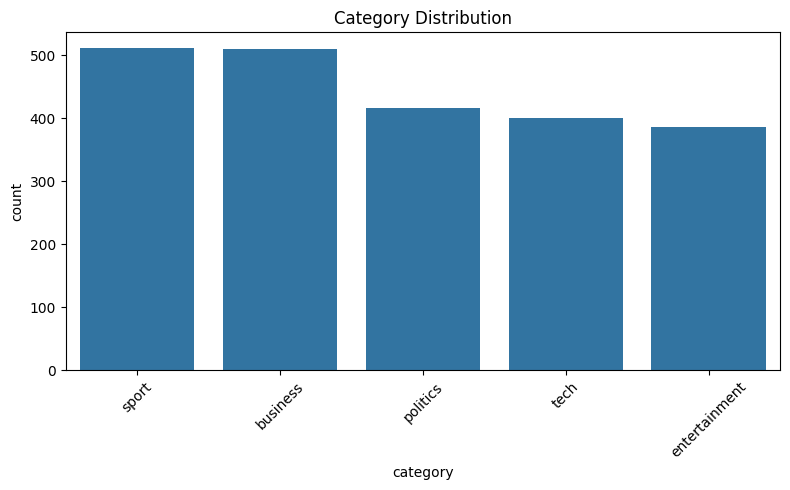

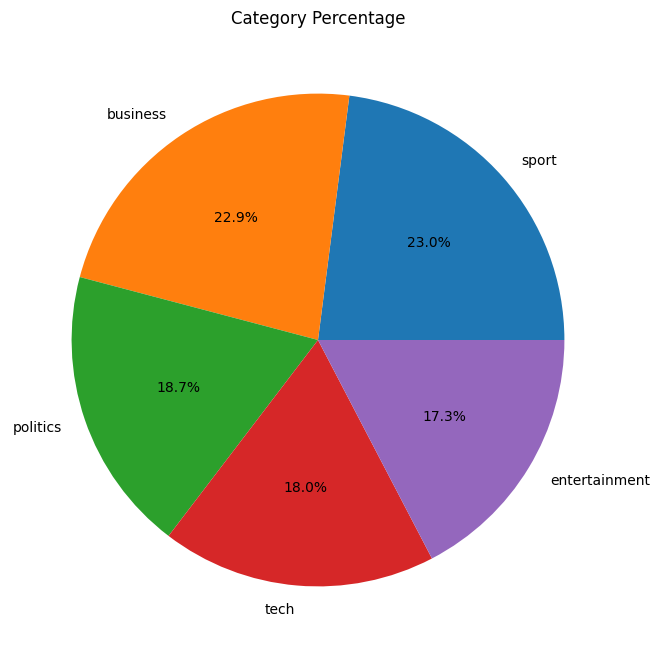

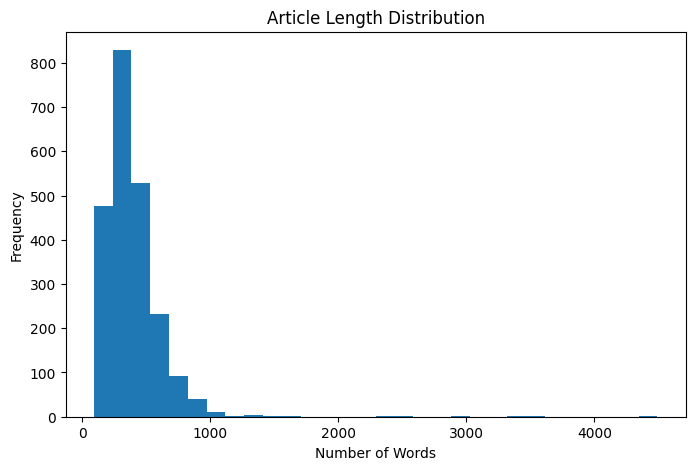


TASK 2 : TEXT PREPROCESSING

Sample Cleaned Text:

tv future in the hands of viewers with home theatre systems plasma highdefinition tvs and digital video recorders moving into the living room the way people watch tv will be radically different in five years time that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes with the us leading the trend programmes and other content will be delivered to viewers via home netwo

First Tokenized Sequence:
[178, 241, 7, 2, 1252, 4, 1234, 18, 126, 1146, 793, 5087, 1284, 4156, 5, 216, 260, 4016, 1429, 77, 2, 1353, 1667, 2, 117, 46, 979, 178, 24, 17, 6379, 401, 7, 185, 81, 73, 11, 10, 211, 3, 35, 3036, 1368, 36, 2464, 22, 2, 639, 493, 1299]

Padded Shape:
(2225, 500)

TASK 3 : LABEL ENCODING
['business' 'entertainment' 'politics' 'sport' 'tech']

Label Mapping:
business --> 0
politics --> 1
sport --> 2
tech --> 3
entertai

In [19]:
# ============================================================
# BBC NEWS DATASET - TASK 1, TASK 2, TASK 3
# ============================================================

# Install if needed:
# !pip install kagglehub pandas numpy matplotlib seaborn nltk scikit-learn tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Dataset Path:", path)

# ============================================================
# FIND CSV FILE
# ============================================================

csv_file = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if csv_file is None:
    raise FileNotFoundError("No CSV file found in dataset directory!")

print("CSV File Found:", csv_file)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(csv_file)

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# IDENTIFY TEXT AND CATEGORY COLUMNS
# ============================================================

# Dataset usually contains:
# title, text/body, category

print("\nColumn Names:")
for col in df.columns:
    print(col)

# Change these if necessary after inspecting columns
text_column = None
category_column = None

for col in df.columns:
    if 'category' in col.lower():
        category_column = col

for col in df.columns:
    if col != category_column:
        text_column = col
        break

# If dataset has title + body columns
if 'body' in df.columns:
    text_column = 'body'
elif 'text' in df.columns:
    text_column = 'text'
elif 'content' in df.columns:
    text_column = 'content'

print("\nText Column:", text_column)
print("Category Column:", category_column)

# ============================================================
# TASK 1 : DATA EXPLORATION
# ============================================================

print("\n==============================")
print("TASK 1 : DATA EXPLORATION")
print("==============================")

# Total Articles
total_articles = len(df)

# Number of Categories
num_categories = df[category_column].nunique()

# Category Distribution
category_distribution = df[category_column].value_counts()

# Article Lengths
df['article_length'] = df[text_column].astype(str).apply(lambda x: len(x.split()))

avg_length = df['article_length'].mean()
longest_article = df['article_length'].max()
shortest_article = df['article_length'].min()

print("\nTotal Articles:", total_articles)
print("Number of Categories:", num_categories)

print("\nCategory Distribution:")
print(category_distribution)

print("\nAverage Article Length:", round(avg_length, 2))
print("Longest Article Length:", longest_article)
print("Shortest Article Length:", shortest_article)

# ============================================================
# VISUALIZATION 1 : COUNT PLOT
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(
    x=category_column,
    data=df,
    order=df[category_column].value_counts().index
)
plt.title("Category Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2 : PIE CHART
# ============================================================

plt.figure(figsize=(8,8))
df[category_column].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Category Percentage")
plt.ylabel("")
plt.show()

# ============================================================
# VISUALIZATION 3 : HISTOGRAM
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(df['article_length'], bins=30)
plt.title("Article Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# TASK 2 : TEXT PREPROCESSING
# ============================================================

print("\n==============================")
print("TASK 2 : TEXT PREPROCESSING")
print("==============================")

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df[text_column].astype(str).apply(preprocess_text)

print("\nSample Cleaned Text:\n")
print(df['clean_text'].iloc[0][:500])

# ============================================================
# TOKENIZATION
# ============================================================

MAX_VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("\nFirst Tokenized Sequence:")
print(sequences[0][:50])

# ============================================================
# PADDING
# ============================================================

max_length = 500
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("\nPadded Shape:")
print(padded_sequences.shape)

# ============================================================
# TASK 3 : LABEL ENCODING
# ============================================================

print("\n==============================")
print("TASK 3 : LABEL ENCODING")
print("==============================")

# Required Mapping:
# Business → 0
# Politics → 1
# Sport → 2
# Tech → 3
# Entertainment → 4

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['category'])
print(label_encoder.classes_)

df['category_lower'] = (
    df[category_column]
    .astype(str)
    .str.lower()
    .str.strip()
)

df['label'] = df['category_lower'].map(label_mapping)

print("\nLabel Mapping:")
for k, v in label_mapping.items():
    print(f"{k} --> {v}")

print("\nEncoded Labels Sample:")
print(df[[category_column, 'label']].head())

# ============================================================
# FINAL OUTPUTS
# ============================================================

X = padded_sequences
y = df['label'].values

print("\n====================================")
print("FINAL DATA READY FOR MODEL TRAINING")
print("====================================")


print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("\nVocabulary Size:",
      min(len(tokenizer.word_index)+1,
          MAX_VOCAB_SIZE))

print("Maximum Sequence Length:",
      max_length)

print("\nFirst Encoded Label:", y[0])

# ============================================================
# SAVE PREPROCESSED DATA
# ============================================================

np.save("X_bbc.npy", X)
np.save("y_bbc.npy", y)

df.to_csv(
    "bbc_preprocessed.csv",
    index=False
)

print("\nSaved Files:")
print("1. X_bbc.npy")
print("2. y_bbc.npy")
print("3. bbc_preprocessed.csv")

print("\nAll Tasks Completed Successfully!")

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1780, 500)
(445, 500)


####Task4-baseline LSTM model

In [21]:
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

VOCAB_SIZE = 10000
MAX_LEN = 500

lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dense(64, activation='relu'),

    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_training_time = time.time() - start_time

lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Loss:", lstm_loss)
print("Training Time:", lstm_training_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 380ms/step - accuracy: 0.2647 - loss: 1.5831 - val_accuracy: 0.2528 - val_loss: 1.5858
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 424ms/step - accuracy: 0.3009 - loss: 1.5334 - val_accuracy: 0.2753 - val_loss: 1.5634
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 389ms/step - accuracy: 0.3533 - loss: 1.4654 - val_accuracy: 0.2978 - val_loss: 1.6269
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 446ms/step - accuracy: 0.3608 - loss: 1.4066 - val_accuracy: 0.3427 - val_loss: 1.4900
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.3739 - loss: 1.3532 - val_accuracy: 0.2921 - val_loss: 1.6112
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 427ms/step - accuracy: 0.3652 - loss: 1.3566 - val_accuracy: 0.2921 - val_loss: 1.5128
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - accuracy: 0.3864 - loss: 1.3312 - val_accuracy: 0.3146 - val_loss: 1.4711
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - accuracy: 0.3789 - loss: 1.3112 - val_accu

####Task6 - self-attention model

In [22]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense
)

from tensorflow.keras.models import Model

inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    VOCAB_SIZE,
    128
)(inputs)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(embedding, embedding)

pooled = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pooled)

outputs = Dense(
    5,
    activation='softmax'
)(dense)

attention_model = Model(
    inputs,
    outputs
)

attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

start_time = time.time()

history_attention = attention_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

attention_training_time = time.time() - start_time

attention_loss, attention_acc = attention_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Attention Accuracy:", attention_acc)
print("Attention Loss:", attention_loss)
print("Training Time:", attention_training_time)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │     66,048 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,354,629 (5.17 MB)

 Trainable params: 1,354,629 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.2953 - loss: 1.5244 - val_accuracy: 0.2753 - val_loss: 1.5212
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.4906 - loss: 1.1772 - val_accuracy: 0.6124 - val_loss: 0.9634
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8246 - loss: 0.4960 - val_accuracy: 0.8933 - val_loss: 0.3006
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9650 - loss: 0.1285 - val_accuracy: 0.9438 - val_loss: 0.1535
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9913 - loss: 0.0319 - val_accuracy: 0.9551 - val_loss: 0.1410
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9988 - loss: 0.0088 - val_accuracy: 0.9551 - val_loss: 0.1184
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9494 - val_loss: 0.1156
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9663 - val_loss:

####Task6-Compare Models

In [23]:
comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Loss",
        "Training Time (sec)"
    ],

    "LSTM":[
        lstm_acc,
        lstm_loss,
        lstm_training_time
    ],

    "Self-Attention":[
        attention_acc,
        attention_loss,
        attention_training_time
    ]
})

print(comparison)

                Metric        LSTM  Self-Attention
0             Accuracy    0.460674        0.946067
1                 Loss    1.393546        0.181854
2  Training Time (sec)  270.127333      796.743558


Why Self-Attention performs better?

Answer for report:

LSTM reads words sequentially.
Information from early words may be forgotten.
Self-Attention looks at all words simultaneously.
It captures long-range dependencies better.
Important words receive higher attention weights.
Parallel computation makes training faster.

In [24]:
#Extract Attention Scores
#Modify the attention layer:
attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)

attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

In [25]:
#Create a separate model:
attention_score_model = Model(
    inputs=inputs,
    outputs=attention_scores
)

In [26]:
#Pick a sample article:
sample_text = df['clean_text'].iloc[0]

#Convert:
sequence = tokenizer.texts_to_sequences(
    [sample_text]
)
sequence = pad_sequences(
    sequence,
    maxlen=MAX_LEN,
    padding='post'
)

#Get scores:
scores = attention_score_model.predict(sequence)
print("Scores shape:",scores.shape)

#Average:
word_scores = scores.mean(
    axis=(1,2)
)[0]

#Tokens:
tokens = tokenizer.texts_to_sequences(
    [sample_text]
)[0]

#Words:
index_word = tokenizer.index_word
words = [
    index_word.get(i,"")
    for i in tokens
]

#Display:
for word, score in zip(
    words[:20],
    word_scores[:20]
):
    print(word, score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Scores shape: (1, 4, 500, 500)
tv 0.0019999575
future 0.0020000143
in 0.0020000043
the 0.0020000227
hands 0.0020000043
of 0.001999941
viewers 0.0019999759
with 0.0020000304
home 0.0020000576
theatre 0.0019999705
systems 0.002000114
plasma 0.0019999996
highdefinition 0.0020000373
tvs 0.0020000283
and 0.0020002127
digital 0.001999899
video 0.0020001251
recorders 0.002000036
moving 0.0019999342
into 0.001999859


####Task8-Attention Heatmap

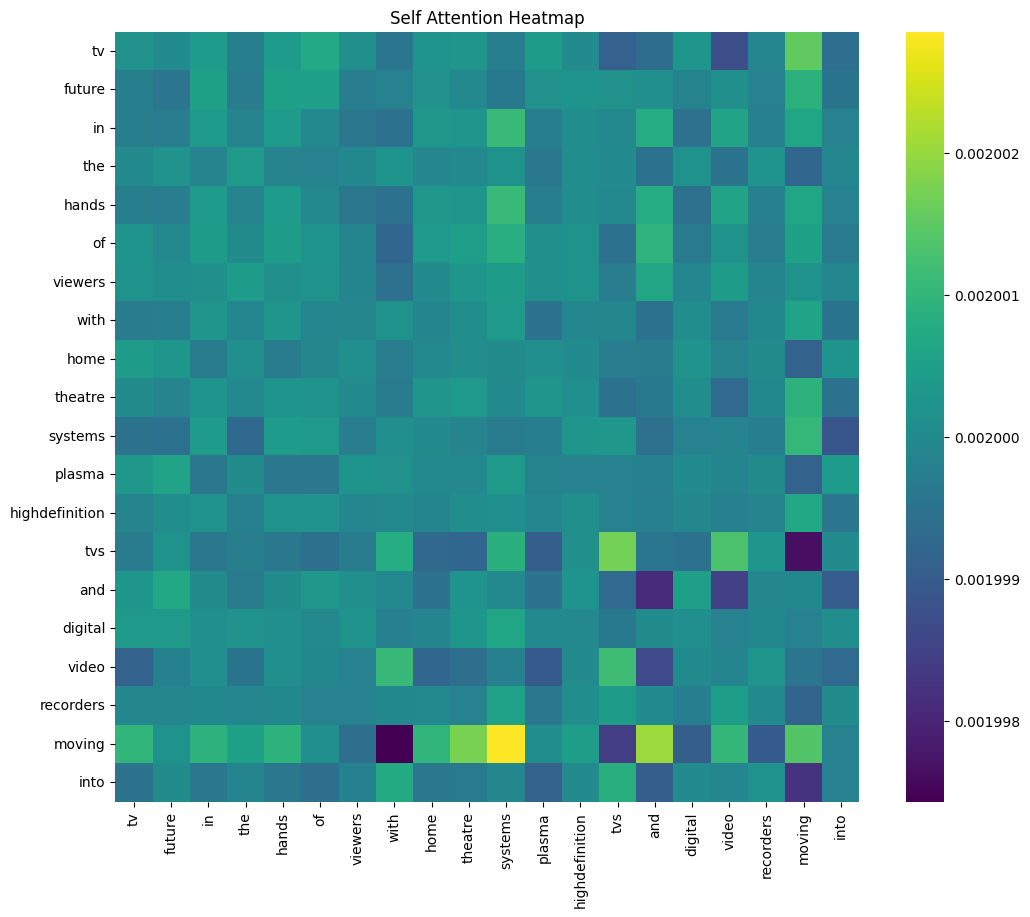

In [27]:
#Take first 20 words:
import seaborn as sns
import matplotlib.pyplot as plt

tokens = tokens[:20]

words = [
    index_word.get(i,"")
    for i in tokens
]

#average attention heads:
heatmap_matrix = scores[
    0,
    0,
    :20,
    :20
]

#Plot:
plt.figure(figsize=(12,10))
sns.heatmap(
    heatmap_matrix,
    xticklabels=words,
    yticklabels=words,
    cmap='viridis'
)
plt.title(
    "Self Attention Heatmap"
)
plt.show()

####Saving models

In [28]:
import pickle

attention_model.save(
    "model.h5"
)

with open(
    "tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(
        tokenizer,
        f
    )

with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        label_encoder,
        f
    )

print("Saved Successfully")

Saved Successfully
